In [2]:
import pickle

with open("./data/3dpw/sequenceFiles/test/downtown_arguing_00.pkl", "rb") as f:
    data = pickle.load(f, encoding="latin1")

In [ ]:
data["cam_intrinsics"]

array([[1.96923077e+03, 0.00000000e+00, 9.60000000e+02],
       [0.00000000e+00, 1.96185286e+03, 5.40000000e+02],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00]])

In [ ]:
data["poses"]

[array([[ 0.01580365,  0.04967087, -0.02887929, ..., -0.13716269,
          0.10291532,  0.20519616],
        [ 0.01303301,  0.05434584, -0.02202675, ..., -0.13812147,
          0.10293581,  0.20643461],
        [ 0.00919168,  0.05758832, -0.01864514, ..., -0.13915564,
          0.10297429,  0.20795524],
        ...,
        [-0.05228349,  0.13795359, -0.02509022, ..., -0.13418138,
          0.10287456,  0.20330148],
        [-0.04794208,  0.13637727, -0.02629179, ..., -0.13458093,
          0.10288873,  0.20415189],
        [-0.04214046,  0.13747194, -0.02816503, ..., -0.13461446,
          0.10289855,  0.20459552]], shape=(898, 72)),
 array([[ 0.11192441, -0.18043954,  0.0090125 , ..., -0.13145503,
          0.10297573,  0.20816723],
        [ 0.10962851, -0.17725246,  0.00704389, ..., -0.13351634,
          0.10303448,  0.21105547],
        [ 0.10597061, -0.17444548,  0.00364058, ..., -0.13443529,
          0.10305807,  0.21225897],
        ...,
        [ 0.00586663, -0.05420788,  0

In [36]:
data["jointPositions"][0][0]

array([ 0.54854517,  0.65308058,  0.29526967,  0.6067764 ,  0.56833399,
        0.27412834,  0.48159859,  0.56350798,  0.28449615,  0.55498663,
        0.77958438,  0.25543452,  0.61404759,  0.16420403,  0.26439937,
        0.44535142,  0.16155147,  0.29119098,  0.55728512,  0.91475461,
        0.27563103,  0.58034389, -0.28074045,  0.19585223,  0.4740886 ,
       -0.2790132 ,  0.23387573,  0.55221668,  0.9688483 ,  0.27721202,
        0.59704333, -0.35163906,  0.32158254,  0.47769424, -0.35091736,
        0.36820347,  0.5279714 ,  1.18027207,  0.23815653,  0.62265203,
        1.0875331 ,  0.25342614,  0.45888629,  1.07900055,  0.25556381,
        0.55096959,  1.27026217,  0.27748203,  0.75334397,  1.10617265,
        0.29522139,  0.34951907,  1.10034164,  0.3208684 ,  0.75715719,
        0.83855337,  0.27639662,  0.32051563,  0.8264512 ,  0.33110742,
        0.7838267 ,  0.56306853,  0.28701458,  0.3204783 ,  0.55215149,
        0.38881944,  0.79579852,  0.47362757,  0.28273736,  0.31

In [38]:
data["cam_poses"][0]

array([[ 0.96789628, -0.02950986, -0.2496116 , -0.42203563],
       [ 0.01017221, -0.98767156,  0.15620949,  0.5437656 ],
       [-0.251144  , -0.15373369, -0.95566346,  4.50547694],
       [ 0.        ,  0.        ,  0.        ,  1.        ]])

In [5]:
data.keys()

dict_keys(['trans_60Hz', 'cam_intrinsics', 'poses', 'img_frame_ids', 'betas_clothed', 'sequence', 'v_template_clothed', 'jointPositions', 'poses_60Hz', 'betas', 'cam_poses', 'campose_valid', 'genders', 'trans', 'poses2d', 'texture_maps'])

In [39]:
import camera
import torch

cam = camera.Camera()
cam.intrinsic = torch.tensor(data["cam_intrinsics"])
cam.rotation = torch.tensor(data["cam_poses"][0, 0:3, 0:3])
cam.translation = torch.tensor(data["cam_poses"][0, 0:3, 3])

In [44]:
joints = cam.project(torch.tensor(data["jointPositions"][0][0]).view(-1, 3))

In [51]:
import dataset

dataset.download_file("./nets/smpl_to_coco.npy", "https://raw.githubusercontent.com/hongsukchoi/Pose2Mesh_RELEASE/refs/heads/master/data/COCO/J_regressor_coco.npy")
dataset.download_file("./nets/smpl.pkl", "https://raw.githubusercontent.com/sampepose/smpl_models/refs/heads/master/SMPL_NEUTRAL.pkl")

In [45]:
joints

tensor([[ 967.8688,  515.6021],
        [ 999.3792,  555.4018],
        [ 938.7031,  557.8080],
        [ 973.9588,  451.4398],
        [1009.0482,  746.6847],
        [ 927.0551,  748.2578],
        [ 970.7191,  385.9894],
        [1006.2794,  939.0713],
        [ 953.7673,  941.4830],
        [ 967.3066,  359.2372],
        [1001.2573,  993.0700],
        [ 940.1373,  997.2689],
        [ 957.3717,  253.2415],
        [1002.6243,  298.7653],
        [ 923.6276,  304.7113],
        [ 962.2672,  207.6114],
        [1062.3270,  288.6866],
        [ 861.9351,  296.4628],
        [1068.9865,  423.1711],
        [ 851.7596,  432.8216],
        [1083.8917,  560.1000],
        [ 848.2562,  570.8568],
        [1091.0286,  603.4898],
        [ 846.6684,  616.1509]], dtype=torch.float64)

In [ ]:
import torch
import smplx

# Initialize SMPL model
model = smplx.create(model_path='path/to/models', model_type='smpl')

# Forward pass to get vertices
output = model(betas=betas, body_pose=body_pose, global_orient=global_orient, transl=translation)
vertices = output.vertices  # Shape: (Batch, 6890, 3)

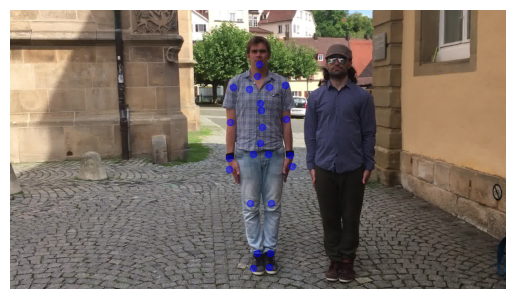

In [49]:
import matplotlib.pyplot as plt
import cv2

img = cv2.imread("./data/3dpw/imageFiles/downtown_arguing_00/image_00000.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # type: ignore

for kp in joints:
    plt.scatter(kp[0], kp[1], s=20, color='#0000ff70')

plt.imshow(img)
plt.axis("off")
plt.show()